In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from marine_qc import (
    do_climatology_check,
    do_date_check,
    do_hard_limit_check,
    do_landlocked_check,
    do_maritime_check,
    do_multiple_individual_check,
    do_position_check,
    do_time_check,
    do_valid_value_check,
    do_wind_consistency_check,
    latitude_longitude_plot,
    latitude_variable_plot,
)

In [3]:
from examples.data import get_climatology_data, get_individual_data

C:\Users\llierham\mobaxterm\.venvs\mp_py\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# How to use quality control checks with individual reports

We need some text!!!

In [4]:
data = get_individual_data()
data

,location,lat,lon,date,sea_surface_temperature,wind_speed,wind_direction
0,Mediterranean Sea,36.0,18.0,2025-06-01 06:00:00,22.8,5.2,135
1,North Sea,54.5,3.0,2025-06-01 12:00:00,13.6,11.4,270
2,South Pacific Ocean,-15.0,-140.0,2025-06-01 18:00:00,27.4,7.8,90
3,"New York, USA",40.7,-74.0,2025-06-02 09:15:00,NaN,4.1,180
4,"Paris, France",48.9,2.3,2025-06-02 14:30:00,NaN,3.5,45
5,"Tokyo, Japan",35.7,139.7,2025-06-03 08:45:00,NaN,6.2,225
6,"Sydney, Australia",-33.9,151.2,2025-06-03 20:10:00,NaN,8.1,160
7,Gulf of Mexico,25.0,-90.0,2025-06-04 11:00:00,29.1,10.5,315
8,Equatorial Atlantic,0.0,-30.0,2025-06-04 16:20:00,28.3,5.9,110
9,Norwegian Sea,60.0,5.0,2025-06-05 07:50:00,8.5,14.3,290


In [5]:
do_position_check(
    lat=data.lat,
    lon=data.lon,
)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [6]:
do_date_check(
    data.date,
)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [7]:
do_time_check(
    data.date,
)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [8]:
do_valid_value_check(
    data.sea_surface_temperature,
)

0    0
1    0
2    0
3    1
4    1
5    1
6    1
7    0
8    0
9    0
dtype: int64

In [9]:
do_hard_limit_check(
    data.sea_surface_temperature,
    limits=(10, 29),
)

0    0
1    0
2    0
3    2
4    2
5    2
6    2
7    1
8    0
9    1
dtype: int64

In [10]:
do_wind_consistency_check(
    wind_speed=data.wind_speed,
    wind_direction=data.wind_direction,
)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64

In [11]:
climatology_data = get_climatology_data()
climatology_data

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 1, latitude: 180, longitude: 360)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-07-01T12:00:00
  * latitude       (latitude) int64 1kB -90 -89 -88 -87 -86 ... 85 86 87 88 89
  * longitude      (longitude) int64 3kB -180 -179 -178 -177 ... 176 177 178 179
Data variables:
    land_sea_mask  (time, latitude, longitude) int8 65kB 1 1 1 1 1 ... 0 0 0 0 0
    sst            (time, latitude, longitude) float64 518kB nan nan ... 0.04343
    sst_stdev1     (time, latitude, longitude) float64 518kB nan nan ... 0.4754
    sst_stdev2     (time, latitude, longitude) float64 518kB nan nan ... 0.8407
    sst_stdev3     (time, latitude, longitude) float64 518kB nan nan ... 0.2352
    crs            int64 8B 0

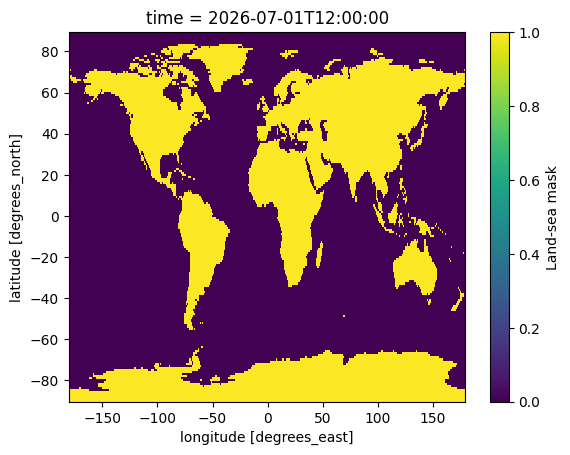

In [12]:
climatology_data.land_sea_mask.plot()

In [13]:
do_landlocked_check(
    lat=data.lat,
    lon=data.lon,
    land_sea_mask=climatology_data.land_sea_mask,
    land_flag=1,
)

0    1
1    1
2    1
3    1
4    0
5    0
6    0
7    1
8    1
9    1
dtype: int64

In [14]:
do_maritime_check(
    lat=data.lat,
    lon=data.lon,
    sea_land_mask=climatology_data.land_sea_mask,
    sea_flag=0,
)

0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    0
8    0
9    0
dtype: int64

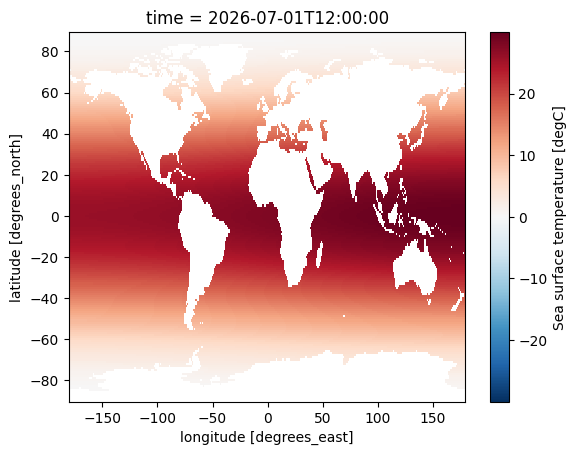

In [15]:
climatology_data.sst.plot()

In [16]:
climatology_check = do_climatology_check(
    value=data.sea_surface_temperature,
    climatology=climatology_data.sst,
    maximum_anomaly=5.0,
    lat=data.lat,
    lon=data.lon,
)
climatology_check

0    0
1    0
2    0
3    2
4    2
5    2
6    2
7    1
8    0
9    0
dtype: int64

In [17]:
qc_dict = {
    "positional_check": {
        "func": "do_position_check",
        "names": {
            "lat": "lat",
            "lon": "lon",
        },
    },
    "date_check": {
        "func": "do_date_check",
        "names": {"date": "date"},
    },
    "time_check": {
        "func": "do_time_check",
        "names": {"date": "date"},
    },
    "hard_limit_check": {"func": "do_hard_limit_check", "names": {"value": "sea_surface_temperature"}, "arguments": {"limits": (10, 29)}},
    "landlocked_check": {
        "func": "do_landlocked_check",
        "names": {
            "lat": "lat",
            "lon": "lon",
        },
        "arguments": {
            "land_sea_mask": climatology_data.land_sea_mask,
            "land_flag": 1,
        },
    },
    "maritime_check": {
        "func": "do_maritime_check",
        "names": {
            "lat": "lat",
            "lon": "lon",
        },
        "arguments": {
            "sea_land_mask": climatology_data.land_sea_mask,
            "sea_flag": 1,
        },
    },
    "climatology_check": {
        "func": "do_climatology_check",
        "names": {"value": "sea_surface_temperature"},
        "arguments": {
            "climatology": climatology_data.sst,
            "maximum_anomaly": 5.0,
            "lat": data.lat,
            "lon": data.lon,
        },
    },
}
do_multiple_individual_check(
    data,
    qc_dict,
)

,positional_check,date_check,time_check,hard_limit_check,landlocked_check,maritime_check,climatology_check
0,0,0,0,0,1,1,0
1,0,0,0,0,1,1,0
2,0,0,0,0,1,1,0
3,0,0,0,2,1,1,2
4,0,0,0,2,0,0,2
5,0,0,0,2,0,0,2
6,0,0,0,2,0,0,2
7,0,0,0,1,1,1,1
8,0,0,0,0,1,1,0
9,0,0,0,1,1,1,0


In [18]:
do_multiple_individual_check(
    data,
    qc_dict,
    return_method="failed",
)

,positional_check,date_check,time_check,hard_limit_check,landlocked_check,maritime_check,climatology_check
0,0,0,0,0,1,3,3
1,0,0,0,0,1,3,3
2,0,0,0,0,1,3,3
3,0,0,0,2,1,3,3
4,0,0,0,2,0,0,2
5,0,0,0,2,0,0,2
6,0,0,0,2,0,0,2
7,0,0,0,1,3,3,3
8,0,0,0,0,1,3,3
9,0,0,0,1,3,3,3


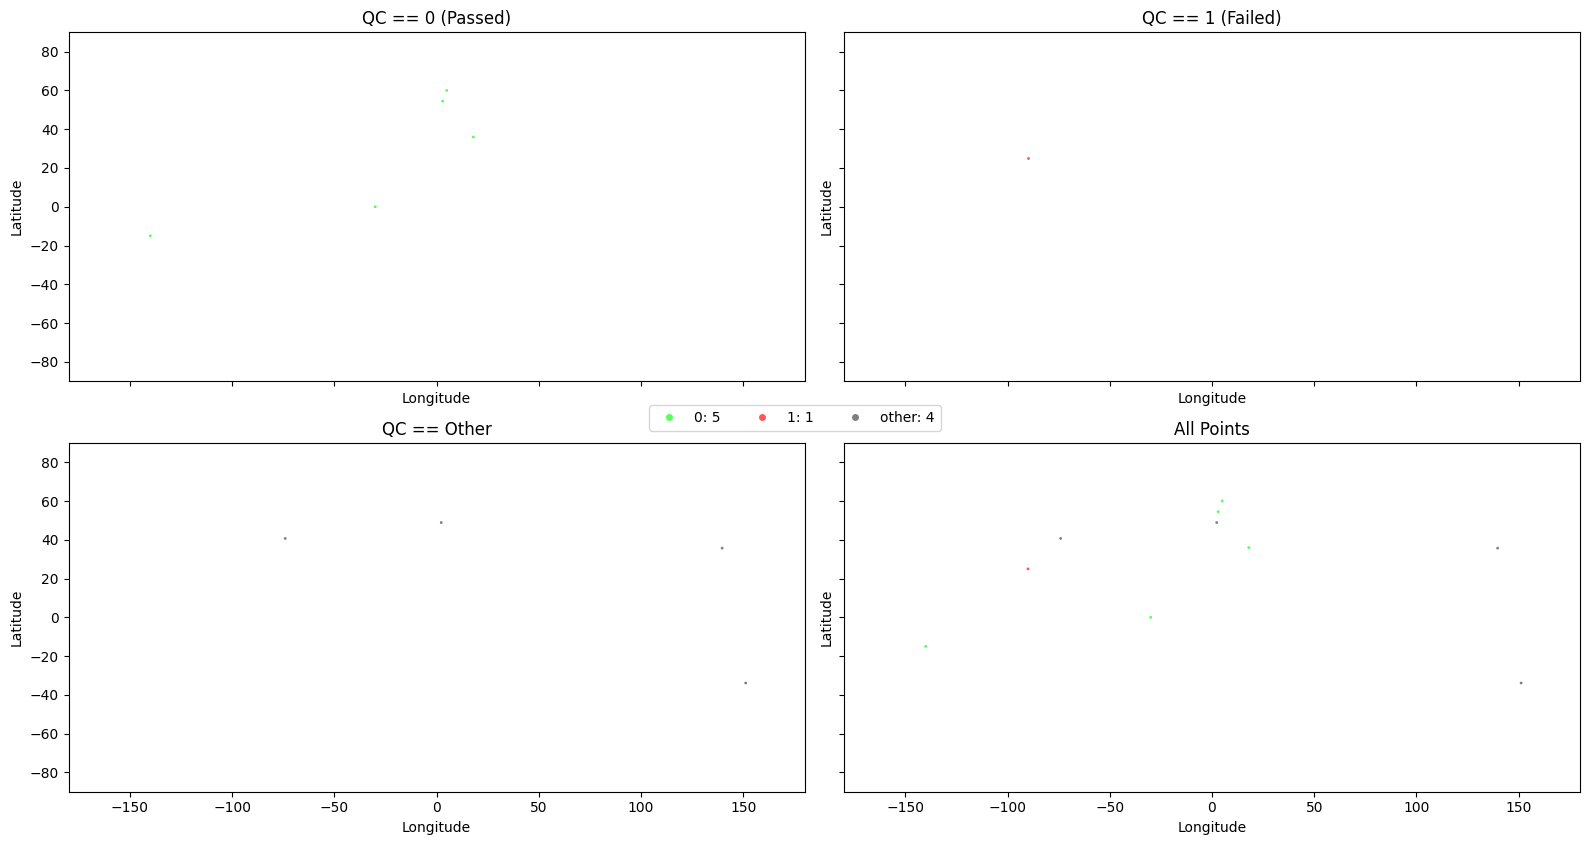

In [19]:
lat_lon_plot = latitude_longitude_plot(
    lat=data.lat,
    lon=data.lon,
    qc_outcomes=climatology_check,
)

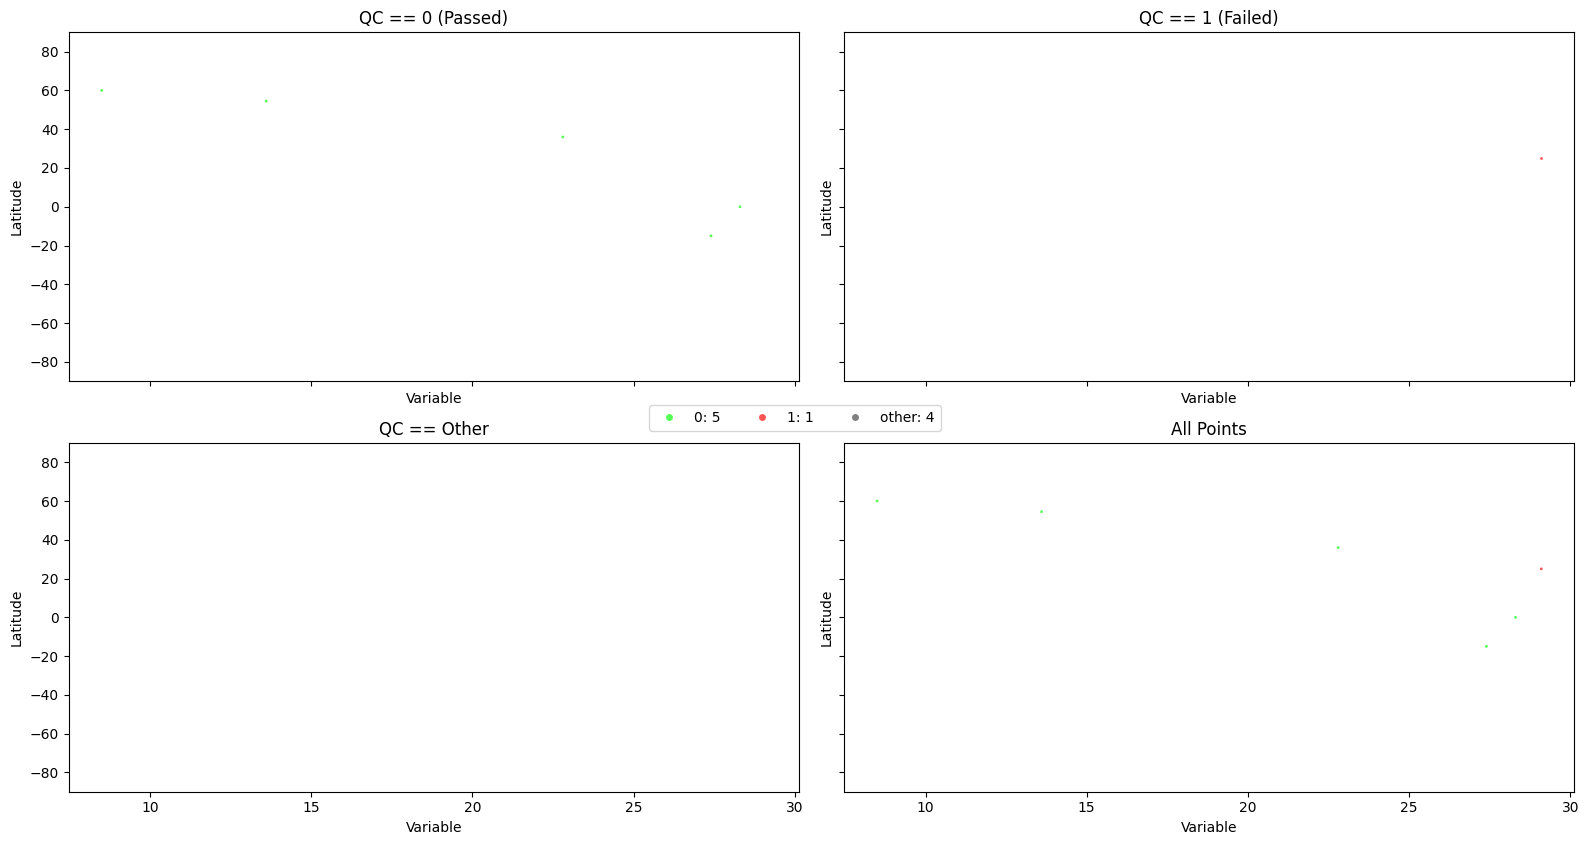

In [20]:
lat_var_plot = latitude_variable_plot(
    lat=data.lat,
    value=data.sea_surface_temperature,
    qc_outcomes=climatology_check,
)